# Gradient Accumulation

Large batch sizes improve training stability and convergence for LLMs,
but a single GPU often can't fit a large batch in memory.

**Gradient accumulation** solves this: run several small ("micro") batches,
accumulate their gradients, then do one optimizer step. Mathematically
identical to a single large batch.

This notebook covers:
1. **Why batch size matters** — noise, convergence, and the critical batch size
2. **How accumulation works** — step by step
3. **Implementation** — from scratch, then matching `trainer.py:117-141`
4. **Comparison** — same effective batch size, with and without accumulation

### References
- Implementation: `src/ai_playground/training/trainer.py` lines 117-141
- Scaling laws for batch size: ["An Empirical Model of Large-Batch Training"](https://arxiv.org/abs/1812.06162) (McCandlish et al., 2018)
- [docs/PAPERS.md § Training Optimization](../../docs/PAPERS.md#training-optimization)

In [1]:
import sys
sys.path.insert(0, '../src')

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import math

from ai_playground.models import Transformer, TransformerConfig

torch.manual_seed(42)
device = 'cpu'

## 1. Why Batch Size Matters

Each training step computes gradients from a batch of examples.

- **Small batch** (e.g., 1): gradients are very noisy — each step is based on
  a single example, so the direction is unreliable. Lots of zig-zagging.
- **Large batch** (e.g., 64): gradients average over many examples — the direction
  is more reliable. Smoother convergence.

But large batches need more GPU memory: batch_size × seq_len × dim × layers.
At some point, you run out of VRAM.

**Gradient accumulation** lets you get the statistical benefit of a large batch
without the memory cost.

In [2]:
# Setup: more training data to see batch size effects
VOCAB = ['<pad>', 'the', 'cat', 'dog', 'sat', 'ran', 'on', 'mat']
tok2id = {t: i for i, t in enumerate(VOCAB)}
sentences = [
    'the cat sat on the mat', 'the dog ran on the mat',
    'the cat ran on the mat', 'the dog sat on the mat',
    'the cat sat on the mat', 'the dog ran on the mat',
    'the cat ran on the mat', 'the dog sat on the mat',  # repeated for batching
]
all_tok = [[tok2id[w] for w in s.split()] for s in sentences]
all_x = torch.tensor([t[:-1] for t in all_tok])  # (8, 5)
all_y = torch.tensor([t[1:] for t in all_tok])

def make_model(seed=42):
    torch.manual_seed(seed)
    cfg = TransformerConfig(
        vocab_size=len(VOCAB), dim=32, n_layers=2, n_heads=4,
        n_kv_heads=2, max_seq_len=16, ffn_dim_multiplier=2.0,
    )
    return Transformer(cfg).to(device)

print(f'Dataset: {all_x.shape[0]} sentences, {all_x.shape[1]} tokens each')

Dataset: 8 sentences, 5 tokens each


## 2. How Gradient Accumulation Works

Instead of:
```
big_batch → forward → loss → backward → optimizer.step()
```

We do:
```
micro_batch_1 → forward → loss/N → backward    (accumulate gradients)
micro_batch_2 → forward → loss/N → backward    (accumulate gradients)
...N times...
optimizer.step()                                 (one update with summed gradients)
```

The key: **don't call `optimizer.zero_grad()` between micro-batches.**
PyTorch accumulates gradients by default — calling `.backward()` *adds*
to the existing `.grad` tensors.

Divide loss by N so the gradient magnitude matches a single large batch.

In [3]:
# Demonstrate that accumulated gradients equal large-batch gradients
model_big = make_model(seed=42)
model_accum = make_model(seed=42)

# Method 1: One big batch (batch_size=4)
big_x = all_x[:4]
big_y = all_y[:4]

logits_big = model_big(big_x)
loss_big = F.cross_entropy(logits_big.view(-1, len(VOCAB)), big_y.view(-1))
loss_big.backward()

grad_big = model_big.tok_embeddings.weight.grad.clone()

# Method 2: Two micro-batches of 2, accumulated
accum_steps = 2
micro_size = 2

for i in range(accum_steps):
    start = i * micro_size
    micro_x = all_x[start:start + micro_size]
    micro_y = all_y[start:start + micro_size]
    
    logits = model_accum(micro_x)
    loss = F.cross_entropy(logits.view(-1, len(VOCAB)), micro_y.view(-1))
    loss = loss / accum_steps  # Divide by N!
    loss.backward()  # Gradients accumulate (no zero_grad between steps)

grad_accum = model_accum.tok_embeddings.weight.grad.clone()

# Compare
diff = (grad_big - grad_accum).abs().max().item()
print(f'Max gradient difference: {diff:.10f}')
print(f'Gradients match: {diff < 1e-5} ✅' if diff < 1e-5 else f'Gradients differ! ❌')
print(f'\nThis proves: 2 micro-batches of 2 = 1 batch of 4 (mathematically identical)')

Max gradient difference: 0.0000000894
Gradients match: True ✅

This proves: 2 micro-batches of 2 = 1 batch of 4 (mathematically identical)


## 3. Training Comparison

Let's train with:
- **Batch=2, no accumulation** (effective batch = 2, noisy)
- **Batch=2, accum=4** (effective batch = 8, smooth)
- **Batch=8, no accumulation** (effective batch = 8, ground truth)

The last two should produce very similar loss curves.

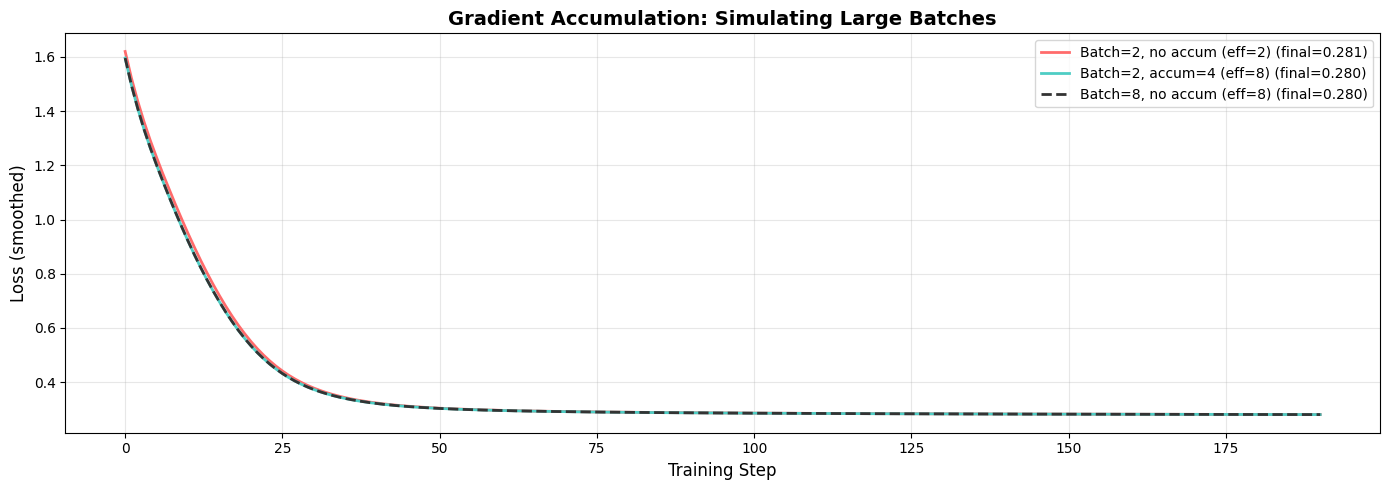

Observations:
- Batch=2 (no accum) is noisier — fewer examples per gradient estimate
- Batch=2 with accum=4 closely matches batch=8 — same effective batch size!
- The accumulated version uses only 2 samples of memory, but gets batch-8 quality


In [4]:
def train_with_accum(micro_batch_size, accum_steps, n_steps=200, seed=42):
    """Train and return loss history.
    
    Effective batch size = micro_batch_size × accum_steps.
    This matches the logic in trainer.py:117-141.
    """
    torch.manual_seed(seed)
    model = make_model(seed)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)
    
    eff_batch = micro_batch_size * accum_steps
    losses = []
    model.train()
    
    for step in range(n_steps):
        optimizer.zero_grad()  # Zero once per effective batch
        total_loss = 0.0
        
        for micro in range(accum_steps):
            # Cycle through data
            start = ((step * accum_steps + micro) * micro_batch_size) % len(all_x)
            end = start + micro_batch_size
            if end > len(all_x):
                start = 0
                end = micro_batch_size
            
            x = all_x[start:end]
            y = all_y[start:end]
            
            logits = model(x)
            loss = F.cross_entropy(logits.view(-1, len(VOCAB)), y.view(-1))
            loss = loss / accum_steps  # Scale loss by accumulation steps
            loss.backward()  # Accumulate gradients
            total_loss += loss.item()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(total_loss)
    
    return losses

# Run experiments
results = [
    ('Batch=2, no accum (eff=2)',   train_with_accum(2, 1), '#FF6B6B'),
    ('Batch=2, accum=4 (eff=8)',    train_with_accum(2, 4), '#4ECDC4'),
    ('Batch=8, no accum (eff=8)',   train_with_accum(8, 1), '#333333'),
]

fig, ax = plt.subplots(figsize=(14, 5))
for name, losses, color in results:
    # Smooth for readability
    smooth = np.convolve(losses, np.ones(10)/10, mode='valid')
    ls = '--' if 'eff=8' in name and 'no accum' in name else '-'
    ax.plot(smooth, label=f'{name} (final={losses[-1]:.3f})', color=color, linewidth=2, linestyle=ls)

ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Loss (smoothed)', fontsize=12)
ax.set_title('Gradient Accumulation: Simulating Large Batches', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Observations:')
print('- Batch=2 (no accum) is noisier — fewer examples per gradient estimate')
print('- Batch=2 with accum=4 closely matches batch=8 — same effective batch size!')
print('- The accumulated version uses only 2 samples of memory, but gets batch-8 quality')

## 4. Memory vs Compute Tradeoff

Gradient accumulation trades **time for memory**:

| | Batch=8 | Batch=2, accum=4 |
|--|---------|------------------|
| **GPU memory** | 4x more activations | 1x (small batch) |
| **Compute per step** | 1 forward + 1 backward | 4 forward + 4 backward |
| **Gradient quality** | Identical | Identical |
| **Wall-clock time** | Faster (one pass) | ~Same or slower |

The compute is the same total FLOPs either way — you're doing the same
number of forward/backward passes. The only overhead is that micro-batches
can't be parallelized as efficiently on the GPU.

In practice, accumulation is essential when your model is so large that
even batch_size=1 barely fits. LLaMA-65B training used `grad_accum_steps=32`
with micro_batch_size=1 per GPU.

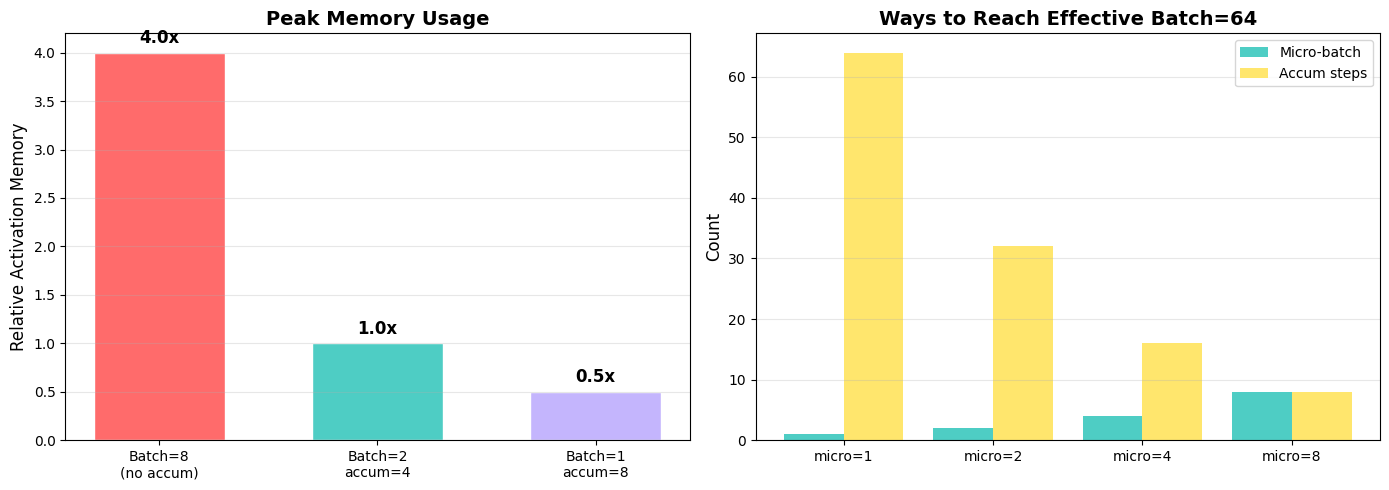

All configurations above produce identical gradients.
Choose micro-batch size based on what fits in your GPU memory.


In [5]:
# Visualize the memory/batch tradeoff
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: memory usage
scenarios = ['Batch=8\n(no accum)', 'Batch=2\naccum=4', 'Batch=1\naccum=8']
mem_relative = [4.0, 1.0, 0.5]  # relative to batch=2
colors_mem = ['#FF6B6B', '#4ECDC4', '#C4B5FD']

ax1.bar(scenarios, mem_relative, color=colors_mem, edgecolor='white', width=0.6)
ax1.set_ylabel('Relative Activation Memory', fontsize=12)
ax1.set_title('Peak Memory Usage', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mem_relative):
    ax1.text(i, v + 0.1, f'{v:.1f}x', ha='center', fontsize=12, fontweight='bold')

# Right: effective batch size options for a fixed memory budget
memory_budget = 8  # GB (example)
batch_sizes = [1, 2, 4, 8]
accum_to_reach_64 = [64 // b for b in batch_sizes]

ax2.bar(range(len(batch_sizes)),
        [b for b in batch_sizes], color='#4ECDC4', label='Micro-batch', width=0.4)
ax2.bar([x + 0.4 for x in range(len(batch_sizes))],
        accum_to_reach_64, color='#FFE66D', label='Accum steps', width=0.4)
ax2.set_xticks([x + 0.2 for x in range(len(batch_sizes))])
ax2.set_xticklabels([f'micro={b}' for b in batch_sizes])
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Ways to Reach Effective Batch=64', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('All configurations above produce identical gradients.')
print('Choose micro-batch size based on what fits in your GPU memory.')

## Key Takeaways

1. **Gradient accumulation** = run N micro-batches, accumulate gradients, then update once. Mathematically identical to a single large batch.
2. The trick: **don't zero gradients** between micro-batches, and **divide loss by N**.
3. **Trades time for memory** — same total compute, but fits in less VRAM.
4. **Essential for large model training** — LLaMA, GPT-4, etc. all use this because even batch=1 is tight on memory.
5. Implementation in `trainer.py:117-141` does exactly this loop.

### References
- [An Empirical Model of Large-Batch Training](https://arxiv.org/abs/1812.06162) (McCandlish et al., 2018)
- [docs/PAPERS.md § Training Optimization](../../docs/PAPERS.md#training-optimization)

### Next: `04_adamw_from_scratch.ipynb` — build the optimizer step by step